In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=605c3457dd050f8c3b332e36581529d4d8627e24e94021e777a271066a6e543f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [16]:
from qiskit import QuantumCircuit

qc = QuantumCircuit.from_qasm_file("P4_gentle_mound.qasm")

print("Qubits:", qc.num_qubits)
print("Depth:", qc.depth())

Qubits: 40
Depth: 25


In [15]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving P4_gentle_mound.qasm to P4_gentle_mound.qasm
{'P4_gentle_mound.qasm': b'OPENQASM 2.0;\r\ninclude "qelib1.inc";\r\nqreg q[40];\r\nu3(1.310348048679427,5.996559851204409,4.119422323252348) q[0];\r\nu3(1.0454110698218484,1.5732569787559234,0.5890001145474622) q[1];\r\nu3(1.48108197974125,4.076874818240874,3.923839322567847) q[2];\r\nu3(2.7416986599726316,1.2722857237672487,1.5520048218192384) q[3];\r\nu3(2.25463593411878,0.40655938074023695,3.9072244916264323) q[4];\r\nu3(1.632534291820342,4.833906046724869,6.036191800794699) q[5];\r\nu3(1.2677808308991712,0.8192479793806309,3.7575402284491353) q[6];\r\nu3(2.17136040592373,1.4160558928524074,3.0416346115268973) q[7];\r\nu3(1.6465232165895827,5.314552687820069,3.094043796615274) q[8];\r\nu3(1.8975358405062424,4.870472821590138,0.6118342239025937) q[9];\r\nu3(2.2145735236234487,3.8605303308419834,0.6671714877564623) q[10];\r\nu3(1.2843584017837253,4.127378261421356,4.536138526788237) q[11];\r\ncz q[11],q[6];\r\nu3(1.4817589520949443,

In [17]:
qc.draw("mpl")

In [18]:
qc.measure_all()

In [19]:
from qiskit_aer import AerSimulator

simulator = AerSimulator(
    method="matrix_product_state",
    matrix_product_state_max_bond_dimension=64
)

result = simulator.run(qc, shots=400).result()

counts = result.get_counts()

In [20]:
peak = max(counts, key=counts.get)

print("Peak bitstring:", peak)
print("Count:", counts[peak])

Peak bitstring: 1011011000101000010011001110100001010110
Count: 13


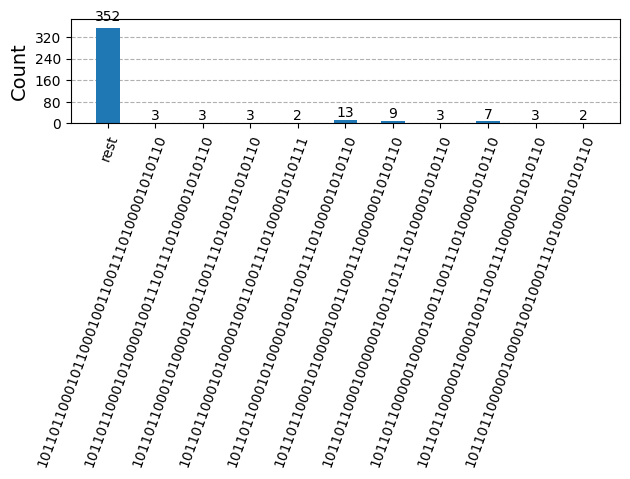

In [21]:
from qiskit.visualization import plot_histogram

plot_histogram(counts, sort='desc', number_to_keep=10)

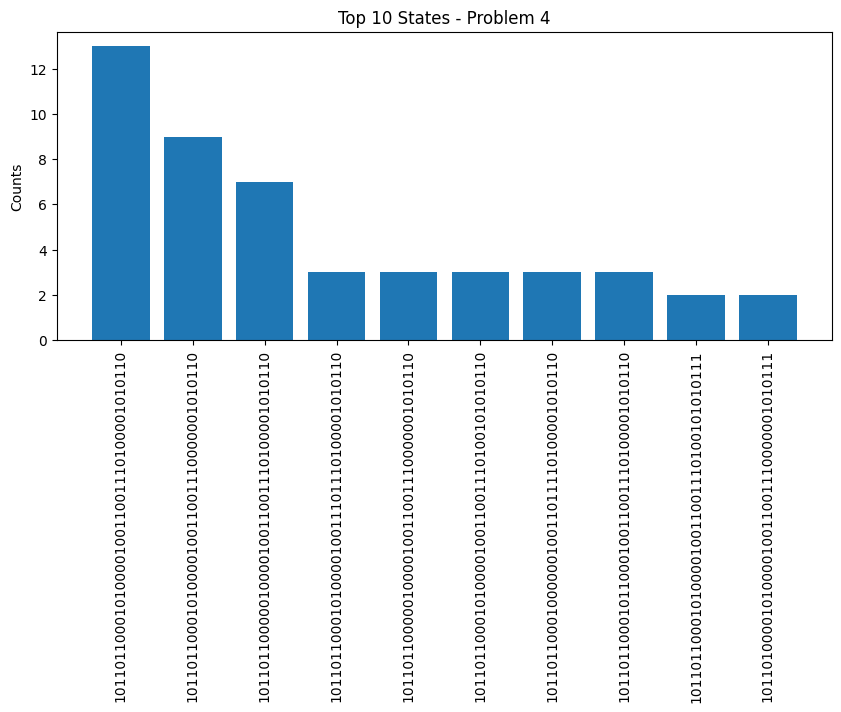

In [22]:
import matplotlib.pyplot as plt

top_states = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]

states = [s for s, c in top_states]
values = [c for s, c in top_states]

plt.figure(figsize=(10,4))
plt.bar(states, values)
plt.xticks(rotation=90)
plt.title("Top 10 States - Problem 4")
plt.ylabel("Counts")
plt.show()